# 03 – Privacy & Governance Analysis
**Role:** Governance Officer  
**Project:** NovaCred Credit Application Governance Audit  
**Course:** DEGO 2606 – Nova SBE  


**Input:** `../data/credit_applications_clean_final.csv` (498 records, produced by `01-data-quality.ipynb`)


## Table of Contents

1. PII Identification and Risk Assessment  
2. Pseudonymization and Data Minimization  
3. GDPR Compliance Gap Analysis  
   - 3.1 Penalty Tier Mapping and Estimated Exposure  
   - 3.2 Data Lifecycle Governance Map  
   - 3.3 GDPR Data Subject Rights  
4. EU AI Act Classification  
5. Actionable Governance Controls  
   - 5.1 Immediate Actions (0–3 months)  
   - 5.2 Short-Term Actions (3–6 months)  
   - 5.3 Long-Term Actions (6–12 months)  
   - 5.4 AI Governance Implementation Checklist  
   - 5.5 Governance Roles and Responsibilities  
   - 5.6 ML Pipeline Leakage Risk


In [1]:
import pandas as pd
import numpy as np
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_PATH = Path("../data/credit_applications_clean_final.csv")
df = pd.read_csv(DATA_PATH)
df["applicant_info.date_of_birth"] = pd.to_datetime(
    df["applicant_info.date_of_birth"], errors="coerce"
)

print(f"Dataset loaded: {len(df)} records, {len(df.columns)} columns")
df.head(3)


Dataset loaded: 498 records, 22 columns


,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes,_missing_critical_financials
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15 00:00:00+00:00,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036.0,...,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,0
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,Male,1992-03-31,10032.0,...,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN,0
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075.0,...,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN,0


## 1. PII Identification

**GDPR Art. 4(1):** Personal data = any information relating to an identified or 
identifiable natural person.

Cross-notebook evidence already established:
- **Notebook 01:** 3 SSNs shared across different applicants — accuracy violation (Art. 5(1)(d))
- **Notebook 02:** ZIP code confirmed as proxy for gender — female-majority region has lowest approval rate (52%)


In [2]:
# Section 1: PII Inventory
# Identifies all personal data fields under GDPR Art. 4(1)

pii_inventory = [
    {"Column": "applicant_info.full_name",    "PII Type": "Direct PII",    "GDPR Article": "Art. 4(1)",           "Risk": "High",     "Finding": "Present in 100% of records; plain text; enables direct identification"},
    {"Column": "applicant_info.email",         "PII Type": "Direct PII",    "GDPR Article": "Art. 4(1)",           "Risk": "High",     "Finding": "Present in 100% of records; unique identifier"},
    {"Column": "applicant_info.ssn",           "PII Type": "Direct PII",    "GDPR Article": "Art. 87",             "Risk": "Critical", "Finding": "3 SSNs shared across different people — accuracy breach (notebook 01)"},
    {"Column": "applicant_info.ip_address",    "PII Type": "Indirect PII",  "GDPR Article": "Art. 4(1) Recital 30","Risk": "Medium",   "Finding": "Enables geolocation and device fingerprinting; missing in 4 records"},
    {"Column": "applicant_info.date_of_birth", "PII Type": "Direct PII",    "GDPR Article": "Art. 4(1)",           "Risk": "High",     "Finding": "Combined with name = strong re-identification risk; missing in 4 records"},
    {"Column": "applicant_info.gender",        "PII Type": "Direct PII",    "GDPR Article": "Art. 4(1) / Art. 9", "Risk": "High",     "Finding": "Used in lending model; DI ratio = 0.767 (notebook 02)"},
    {"Column": "applicant_info.zip_code",      "PII Type": "Indirect PII",  "GDPR Article": "Art. 4(1)",           "Risk": "Medium",   "Finding": "Confirmed proxy for gender in notebook 02"},
    {"Column": "spending_behavior",            "PII Type": "Behavioural PII","GDPR Article": "Art. 5(1)(c)",       "Risk": "High",     "Finding": "Granular spending categories build sensitive profile; necessity not demonstrated"},
]

pii_df = pd.DataFrame(pii_inventory)
print(f"=== PII Fields Identified: {len(pii_df)} total ===\n")
print(pii_df[["Column", "PII Type", "Risk", "GDPR Article"]].to_string(index=False))
print(f"\nRisk breakdown:\n{pii_df['Risk'].value_counts().to_string()}")


=== PII Fields Identified: 8 total ===

                      Column        PII Type     Risk         GDPR Article
    applicant_info.full_name      Direct PII     High            Art. 4(1)
        applicant_info.email      Direct PII     High            Art. 4(1)
          applicant_info.ssn      Direct PII Critical              Art. 87
   applicant_info.ip_address    Indirect PII   Medium Art. 4(1) Recital 30
applicant_info.date_of_birth      Direct PII     High            Art. 4(1)
       applicant_info.gender      Direct PII     High   Art. 4(1) / Art. 9
     applicant_info.zip_code    Indirect PII   Medium            Art. 4(1)
           spending_behavior Behavioural PII     High         Art. 5(1)(c)

Risk breakdown:
Risk
High        5
Medium      2
Critical    1


### 1.x PII Risk Level Overview (Visualization)

To summarise the PII assessment, we visualise how many fields fall into each risk level (e.g. High, Medium, Critical) based on our GDPR analysis.


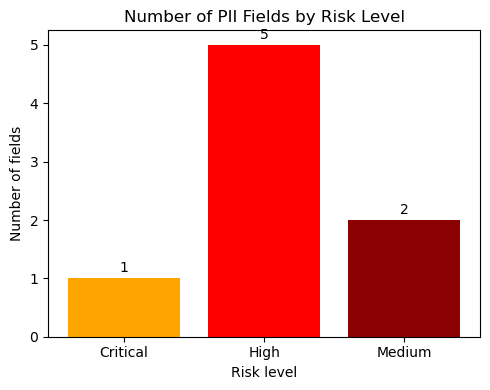

In [3]:
import matplotlib.pyplot as plt

# Count fields by risk level from the existing PII inventory
risk_counts = pii_df["Risk"].value_counts().sort_index()

plt.figure(figsize=(5, 4))
bars = plt.bar(risk_counts.index, risk_counts.values, color=["orange", "red", "darkred"])

plt.title("Number of PII Fields by Risk Level")
plt.xlabel("Risk level")
plt.ylabel("Number of fields")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05,
        int(height),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## 2. Pseudonymization of Direct Identifiers (with Salted Hashing)

To reduce re-identification risk while keeping the dataset usable for analytics, we pseudonymise direct identifiers such as `name`, `email`, `ssn`, and `ip_address`.

We use **SHA-256** with a fixed **salt** string to derive deterministic pseudonyms:

- The **salt** is a secret value stored separately from the dataset (e.g., in a key management system).
- Salting protects against simple **rainbow table** or dictionary attacks, because an attacker cannot pre-compute hashes without knowing the salt.
- Even after pseudonymization, the data remains personal data under GDPR Art. 4(5), because the same controller could theoretically re-identify individuals using the salt and additional information.

For the purposes of this assignment, we use a static demo salt stored in the notebook. In a real NovaCred deployment, this salt would be stored outside the analytics environment and rotated periodically under strict access control.


In [4]:
import hashlib

# Demo salt for the assignment; in production this must be stored securely and not in the notebook
PSEUDONYMIZATION_SALT = "NovaCred_demo_salt_2024"

def salted_sha256(value: str, salt: str = PSEUDONYMIZATION_SALT) -> str:
    """
    Deterministic salted SHA-256 hash.
    For null/empty values, returns None to avoid creating fake identifiers.
    """
    if pd.isna(value):
        return None
    text = str(value)
    to_hash = (salt + text).encode("utf-8")
    return hashlib.sha256(to_hash).hexdigest()

# Use df and df_pseudo (not novacred_df) in THIS notebook
fields_to_pseudonymize = [
    "applicant_info.full_name",
    "applicant_info.email",
    "applicant_info.ssn",
    "applicant_info.ip_address",
]

# start from the clean dataset
df_pseudo = df.copy()

for field in fields_to_pseudonymize:
    if field in df_pseudo.columns:
        df_pseudo[f"{field}_pseudo"] = df_pseudo[field].apply(salted_sha256)
        df_pseudo.drop(columns=[field], inplace=True)
        print(f"✓ '{field}' pseudonymized")

print("\n--- AFTER pseudonymization (first 3 records) ---")
print(
    df_pseudo[
        [
            "_id",
            "applicant_info.full_name_pseudo",
            "applicant_info.ssn_pseudo",
        ]
    ]
    .head(3)
    .to_string(index=False)
)


✓ 'applicant_info.full_name' pseudonymized
✓ 'applicant_info.email' pseudonymized
✓ 'applicant_info.ssn' pseudonymized
✓ 'applicant_info.ip_address' pseudonymized

--- AFTER pseudonymization (first 3 records) ---
    _id                                  applicant_info.full_name_pseudo                                        applicant_info.ssn_pseudo
app_200 eb8fac8d6a30a5785d4c58175d2e67d9fcf5b9304d35809dbc77934e6c307add cf562a398ae20fbe967b498c969e018a9b597d8ec03b080f130923f7be88841a
app_037 8bdf1d9cc8b2658d62188094e0e48c198535e5e100cef47c9145b6256f95f72c 455362635247fee63ef4c288fd1c94a4ca5fdb1db358d781d8bb7b11619b2089
app_215 1092ef25729cf0493e92f7910af0cce17064b32f57b6234d444c22a406ef58d8 e06423afccdd8d678b8d3bc86eff1f93fcb6208fa501c8bb9c8db9141035dd56


This salted pseudonymization satisfies the GDPR definition of **pseudonymisation** (Art. 4(5)) rather than anonymisation. It significantly raises the technical bar for re-identification, while still allowing NovaCred to link events belonging to the same pseudonymous customer across the dataset.


In [5]:
# Data Minimization: replace date_of_birth with age bracket (GDPR Art. 5(1)(c))
# Age brackets are sufficient for credit risk modeling — exact DOB is not needed

def dob_to_age_bracket(dob):
    """Convert exact date_of_birth to age bracket.
    Implements data minimisation under GDPR Art. 5(1)(c).
    Brackets match those used in bias analysis (notebook 02).
    """
    if pd.isna(dob):
        return "unknown"
    try:
        age = (pd.Timestamp("2024-01-01") - pd.Timestamp(dob)).days // 365
        if age < 18:    return "<18"
        elif age < 31:  return "18-30"
        elif age < 41:  return "31-40"
        elif age < 51:  return "41-50"
        elif age < 66:  return "51-65"
        else:           return "65+"
    except Exception:
        return "unknown"

df_pseudo["age_bracket"] = df["applicant_info.date_of_birth"].apply(dob_to_age_bracket)

print("=== Age Bracket Distribution (replaces raw date_of_birth) ===\n")
print(df_pseudo["age_bracket"].value_counts().sort_index().to_string())
print("\nNote: 18-30 segment has DI = 0.591 — most severe bias found in notebook 02.")
print("Age bracket is sufficient for risk modeling; exact DOB removed to minimise PII.")


=== Age Bracket Distribution (replaces raw date_of_birth) ===

age_bracket
18-30      133
31-40      169
41-50      110
51-65       82
unknown      4

Note: 18-30 segment has DI = 0.591 — most severe bias found in notebook 02.
Age bracket is sufficient for risk modeling; exact DOB removed to minimise PII.


## 3. GDPR Compliance Gap Analysis

All gaps below are grounded in direct evidence from notebooks 01 and 02.
Every field referenced exists in the actual dataset.


In [6]:
# Section 3: GDPR Gap Analysis
# Maps NovaCred's data practices against key GDPR requirements
# All evidence references actual findings from notebooks 01 and 02

gdpr_gaps = [
    {
        "GDPR Article":   "Art. 5(1)(a) – Lawful basis",
        "Dataset Evidence": "No consent_timestamp or lawful_basis field in any of the 498 records",
        "Status": "GAP",
        "Recommendation": "Add consent_timestamp + consent_version at collection; implement consent management platform"
    },
    {
        "GDPR Article":   "Art. 5(1)(c) – Data minimisation",
        "Dataset Evidence": "SSN + IP stored raw; granular spending_behavior categories (Rent, Fitness, Insurance) with no demonstrated necessity",
        "Status": "GAP",
        "Recommendation": "Remove SSN post identity-check; replace DOB with age bracket; aggregate spending into broad categories"
    },
    {
        "GDPR Article":   "Art. 5(1)(d) – Accuracy",
        "Dataset Evidence": "3 SSNs shared across different applicants (notebook 01); gender coded as M/F and Male/Female inconsistently; mixed date formats",
        "Status": "GAP",
        "Recommendation": "Enforce SSN uniqueness constraint at ingestion; add field-level format validation; run quarterly accuracy audits"
    },
    {
        "GDPR Article":   "Art. 5(1)(e) – Storage limitation",
        "Dataset Evidence": "No retention_expiry or deletion_timestamp field in any record",
        "Status": "GAP",
        "Recommendation": "Define retention periods (5 years per financial regulation); implement automated deletion pipeline"
    },
    {
        "GDPR Article":   "Art. 13/14 – Transparency",
        "Dataset Evidence": "No privacy notice or disclosure field; applicants not informed ML model is making decisions",
        "Status": "GAP",
        "Recommendation": "Add privacy notice at point of application; disclose automated decision-making to applicants"
    },
    {
        "GDPR Article":   "Art. 17 – Right to erasure",
        "Dataset Evidence": "No deletion_request_flag or soft-delete mechanism in the dataset",
        "Status": "GAP",
        "Recommendation": "Implement deletion_request_log; build automated erasure workflow keyed on _id"
    },
    {
        "GDPR Article":   "Art. 22 – Automated decisions",
        "Dataset Evidence": "All 498 loan decisions are boolean with zero human_review_flag; no override mechanism",
        "Status": "GAP",
        "Recommendation": "Add human_review_flag; mandate human oversight for all rejections; log override decisions"
    },
    {
        "GDPR Article":   "Art. 25 – Privacy by design",
        "Dataset Evidence": "Raw PII (SSN, full names, IP) stored in plain text; no evidence of access controls",
        "Status": "GAP",
        "Recommendation": "Encrypt PII at rest; apply role-based access control; separate raw PII into a secure vault"
    },
]

gdpr_df = pd.DataFrame(gdpr_gaps)
print(f"=== GDPR Gap Analysis: {len(gdpr_df)} Articles Assessed ===")
print(f"Gaps identified: {(gdpr_df['Status'] == 'GAP').sum()} / {len(gdpr_df)}\n")

for _, row in gdpr_df.iterrows():
    print(f"[{row['Status']}] {row['GDPR Article']}")
    print(f"       Evidence:  {row['Dataset Evidence']}")
    print(f"       Action:    {row['Recommendation']}")
    print()


=== GDPR Gap Analysis: 8 Articles Assessed ===
Gaps identified: 8 / 8

[GAP] Art. 5(1)(a) – Lawful basis
       Evidence:  No consent_timestamp or lawful_basis field in any of the 498 records
       Action:    Add consent_timestamp + consent_version at collection; implement consent management platform

[GAP] Art. 5(1)(c) – Data minimisation
       Evidence:  SSN + IP stored raw; granular spending_behavior categories (Rent, Fitness, Insurance) with no demonstrated necessity
       Action:    Remove SSN post identity-check; replace DOB with age bracket; aggregate spending into broad categories

[GAP] Art. 5(1)(d) – Accuracy
       Evidence:  3 SSNs shared across different applicants (notebook 01); gender coded as M/F and Male/Female inconsistently; mixed date formats
       Action:    Enforce SSN uniqueness constraint at ingestion; add field-level format validation; run quarterly accuracy audits

[GAP] Art. 5(1)(e) – Storage limitation
       Evidence:  No retention_expiry or deletion_ti

In [7]:
# Helper: extract short Article key from "GDPR Article"
gdpr_df["Article"] = gdpr_df["GDPR Article"].str.split("–").str[0].str.strip()
gdpr_df[["GDPR Article", "Article"]]


,GDPR Article,Article
0,Art. 5(1)(a) – Lawful basis,Art. 5(1)(a)
1,Art. 5(1)(c) – Data minimisation,Art. 5(1)(c)
2,Art. 5(1)(d) – Accuracy,Art. 5(1)(d)
3,Art. 5(1)(e) – Storage limitation,Art. 5(1)(e)
4,Art. 13/14 – Transparency,Art. 13/14
5,Art. 17 – Right to erasure,Art. 17
6,Art. 22 – Automated decisions,Art. 22
7,Art. 25 – Privacy by design,Art. 25


### 3.1 GDPR Penalty Tier Mapping and Estimated Exposure

The GDPR defines two main tiers of administrative fines:

- **Tier 1** – up to **€10 million** or **2%** of the total worldwide annual turnover (whichever is higher).
- **Tier 2** – up to **€20 million** or **4%** of the total worldwide annual turnover (whichever is higher).

Based on the lecture, we map each identified NovaCred gap to the relevant penalty tier. For illustration, we assume NovaCred has an annual turnover of **€50 million** and compute the *maximum potential* exposure per article.

> These figures are illustrative maximum caps, not predicted fines. Actual fines depend on severity, duration, intent, mitigation, and cooperation with the DPA.


In [8]:
import pandas as pd

# Start from the GDPR gap dataframe with the new 'Article' helper column
gdpr_penalties = gdpr_df.copy()

# Map each article to a penalty tier (adapt if needed)
tier_mapping = {
    "Art. 5(1)(a)": "Tier 2",   # Lawfulness
    "Art. 5(1)(c)": "Tier 2",   # Data minimisation
    "Art. 5(1)(d)": "Tier 2",   # Accuracy
    "Art. 5(1)(e)": "Tier 2",   # Storage limitation
    "Art. 13/14": "Tier 1",     # Transparency
    "Art. 17": "Tier 2",        # Erasure
    "Art. 22": "Tier 2",        # Automated decisions
    "Art. 25": "Tier 2",        # Privacy by design
}

gdpr_penalties["Penalty tier"] = gdpr_penalties["Article"].map(tier_mapping).fillna("Tier 1")

# Define max fine caps for a hypothetical €50M turnover
turnover_eur = 50_000_000
tier_caps = {
    "Tier 1": {
        "max_eur": max(10_000_000, 0.02 * turnover_eur),
        "max_pct": "2%",
    },
    "Tier 2": {
        "max_eur": max(20_000_000, 0.04 * turnover_eur),
        "max_pct": "4%",
    },
}

def compute_max_fine(tier: str) -> str:
    cap = tier_caps[tier]
    return f"Up to €{cap['max_eur']:,.0f} ({cap['max_pct']} of turnover)"

gdpr_penalties["Max potential fine (illustrative)"] = gdpr_penalties["Penalty tier"].apply(compute_max_fine)

# Qualitative exposure
high_risk_articles = ["Art. 5(1)(a)", "Art. 5(1)(c)", "Art. 5(1)(d)", "Art. 22", "Art. 25"]
gdpr_penalties["Exposure (qualitative)"] = gdpr_penalties["Article"].apply(
    lambda x: "High" if x in high_risk_articles else "Medium"
)

gdpr_penalties


,GDPR Article,Dataset Evidence,Status,Recommendation,Article,Penalty tier,Max potential fine (illustrative),Exposure (qualitative)
0,Art. 5(1)(a) – Lawful basis,No consent_timestamp or lawful_basis field in ...,GAP,Add consent_timestamp + consent_version at col...,Art. 5(1)(a),Tier 2,"Up to €20,000,000 (4% of turnover)",High
1,Art. 5(1)(c) – Data minimisation,SSN + IP stored raw; granular spending_behavio...,GAP,Remove SSN post identity-check; replace DOB wi...,Art. 5(1)(c),Tier 2,"Up to €20,000,000 (4% of turnover)",High
2,Art. 5(1)(d) – Accuracy,3 SSNs shared across different applicants (not...,GAP,Enforce SSN uniqueness constraint at ingestion...,Art. 5(1)(d),Tier 2,"Up to €20,000,000 (4% of turnover)",High
3,Art. 5(1)(e) – Storage limitation,No retention_expiry or deletion_timestamp fiel...,GAP,Define retention periods (5 years per financia...,Art. 5(1)(e),Tier 2,"Up to €20,000,000 (4% of turnover)",Medium
4,Art. 13/14 – Transparency,No privacy notice or disclosure field; applica...,GAP,Add privacy notice at point of application; di...,Art. 13/14,Tier 1,"Up to €10,000,000 (2% of turnover)",Medium
5,Art. 17 – Right to erasure,No deletion_request_flag or soft-delete mechan...,GAP,Implement deletion_request_log; build automate...,Art. 17,Tier 2,"Up to €20,000,000 (4% of turnover)",Medium
6,Art. 22 – Automated decisions,All 498 loan decisions are boolean with zero h...,GAP,Add human_review_flag; mandate human oversight...,Art. 22,Tier 2,"Up to €20,000,000 (4% of turnover)",High
7,Art. 25 – Privacy by design,"Raw PII (SSN, full names, IP) stored in plain ...",GAP,Encrypt PII at rest; apply role-based access c...,Art. 25,Tier 2,"Up to €20,000,000 (4% of turnover)",High


### 3.2 Data Lifecycle Governance Map

The lecture frames GDPR obligations across the full **data lifecycle**:

- **Collection** – lawfulness, transparency, purpose limitation, consent where applicable.
- **Storage** – security, integrity, access control, retention policies.
- **Processing / Use** – fairness, non-discrimination, data minimisation, accountability.
- **Archiving** – limited retention, pseudonymisation where possible, reduced identifiability.
- **Deletion** – erasure, de-identification, and enforcement of retention schedules.

Using the NovaCred dataset and our previous notebooks, we assess compliance at each stage and identify the main gaps and required controls.


In [9]:
lifecycle_data = [
    {
        "Lifecycle stage": "Collection",
        "Key GDPR focus": "Lawfulness, transparency, purpose limitation, consent (Art. 5(1)(a–b), 6, 13/14)",
        "Current NovaCred status": "Non-compliant",
        "Evidence": "No consent / purpose fields; no record of information provided to data subjects; raw SSN requested for all applications.",
        "Required control": "Implement consent and information notices, minimise collected PII (e.g., avoid SSN unless strictly necessary), log legal basis for each data collection."
    },
    {
        "Lifecycle stage": "Storage",
        "Key GDPR focus": "Integrity and confidentiality, security, retention (Art. 5(1)(e), 32)",
        "Current NovaCred status": "Non-compliant",
        "Evidence": "Raw identifiers (name, email, ssn, ip_address, dob) stored in clear text in the core dataset; no retention or archival metadata.",
        "Required control": "Apply pseudonymisation, encrypt identifiers, define retention periods for credit data, separate analytical and operational stores with strict access controls."
    },
    {
        "Lifecycle stage": "Processing / Use",
        "Key GDPR focus": "Fairness, non-discrimination, profiling safeguards (Art. 5(1)(a), 22), data quality (Art. 5(1)(d))",
        "Current NovaCred status": "Non-compliant",
        "Evidence": "Disparate impact against gender and age groups in model outputs; 288 loans approved with missing income; proxy variable (zip_code) strongly correlated with gender.",
        "Required control": "Introduce fairness constraints and monitoring, block decisions when critical features are missing, remove or transform proxy variables, perform regular bias and drift audits."
    },
    {
        "Lifecycle stage": "Archiving",
        "Key GDPR focus": "Storage limitation, further processing safeguards (Art. 5(1)(e))",
        "Current NovaCred status": "Unknown / likely non-compliant",
        "Evidence": "No archival flags or lifecycle metadata in the dataset; no indication of time-based down-sampling or anonymisation for legacy records.",
        "Required control": "Define archival criteria and timelines, pseudonymise or aggregate old records, and ensure archived datasets are segregated with restricted access."
    },
    {
        "Lifecycle stage": "Deletion",
        "Key GDPR focus": "Right to erasure, enforcement of retention schedules (Art. 17, 19)",
        "Current NovaCred status": "Non-compliant",
        "Evidence": "No fields related to deletion requests, no deletion logs, and no mechanism to remove or de-identify an individual across systems.",
        "Required control": "Implement deletion workflows across the data ecosystem, log erasure requests, and propagate deletions to all downstream systems and backups where feasible."
    }
]

lifecycle_df = pd.DataFrame(lifecycle_data)
lifecycle_df


,Lifecycle stage,Key GDPR focus,Current NovaCred status,Evidence,Required control
0,Collection,"Lawfulness, transparency, purpose limitation, ...",Non-compliant,No consent / purpose fields; no record of info...,"Implement consent and information notices, min..."
1,Storage,"Integrity and confidentiality, security, reten...",Non-compliant,"Raw identifiers (name, email, ssn, ip_address,...","Apply pseudonymisation, encrypt identifiers, d..."
2,Processing / Use,"Fairness, non-discrimination, profiling safegu...",Non-compliant,Disparate impact against gender and age groups...,"Introduce fairness constraints and monitoring,..."
3,Archiving,"Storage limitation, further processing safegua...",Unknown / likely non-compliant,No archival flags or lifecycle metadata in the...,"Define archival criteria and timelines, pseudo..."
4,Deletion,"Right to erasure, enforcement of retention sch...",Non-compliant,"No fields related to deletion requests, no del...",Implement deletion workflows across the data e...


This lifecycle view shows that NovaCred’s governance weaknesses are not limited to a single phase (e.g., storage), but are structural across collection, use, and deletion. From a governance officer perspective, this requires an end‑to‑end remediation plan rather than isolated technical fixes.


### 3.3 GDPR Data Subject Rights (Art. 12–21)

The lecture highlighted five core data subject rights that controllers must support:

- **Right of access** (Art. 15) – individuals can obtain a copy of their data and information about processing.
- **Right to rectification** (Art. 16) – individuals can have inaccurate data corrected.
- **Right to erasure** (Art. 17) – individuals can ask for data to be deleted in certain circumstances.
- **Right to data portability** (Art. 20) – individuals can receive their data in a structured, machine-readable format.
- **Right to object** (Art. 21) – individuals can object to certain types of processing, including profiling.

Under GDPR, controllers must normally respond to these requests **within one month**.

We examine whether NovaCred’s current data ecosystem exposes any operational mechanism to honour these rights.


In [10]:
rights_data = [
    {
        "Right": "Access",
        "GDPR Article": "Art. 15",
        "Mechanism present in dataset?": "No",
        "Evidence": "No fields indicating access requests, copies provided, or logs of responses (e.g. no access_request_id, access_response_date, or channel fields).",
        "Gap description": "NovaCred has no visible operational process to let applicants request and obtain a copy of their data and related model information."
    },
    {
        "Right": "Rectification",
        "GDPR Article": "Art. 16",
        "Mechanism present in dataset?": "No",
        "Evidence": "No fields capturing correction requests, previous vs. corrected values, or timestamps of updates initiated by the data subject.",
        "Gap description": "Applicants cannot see and correct inaccurate or outdated information (e.g. income, contact details) through a governed workflow."
    },
    {
        "Right": "Erasure",
        "GDPR Article": "Art. 17",
        "Mechanism present in dataset?": "No",
        "Evidence": "Dataset contains no erasure_request_flag, erasure_date, or deletion_reason, and no indication that records can be removed on request.",
        "Gap description": "There is no implemented right-to-be-forgotten mechanism to delete or de-identify an applicant across systems when conditions are met."
    },
    {
        "Right": "Portability",
        "GDPR Article": "Art. 20",
        "Mechanism present in dataset?": "No",
        "Evidence": "No export logs or fields indicating that applicant data can be provided in a structured, machine-readable format to the data subject or another bank.",
        "Gap description": "NovaCred has no evidence of a process to generate and deliver portable copies of applicant data on request."
    },
    {
        "Right": "Object",
        "GDPR Article": "Art. 21",
        "Mechanism present in dataset?": "No",
        "Evidence": "No flags or fields indicating that an applicant objected to profiling or automated decision-making, nor any mechanism to respect such objections.",
        "Gap description": "Applicants cannot object to the use of automated credit scoring or require that their application be assessed by a human-only process."
    }
]

rights_df = pd.DataFrame(rights_data)
rights_df


,Right,GDPR Article,Mechanism present in dataset?,Evidence,Gap description
0,Access,Art. 15,No,"No fields indicating access requests, copies p...",NovaCred has no visible operational process to...
1,Rectification,Art. 16,No,"No fields capturing correction requests, previ...",Applicants cannot see and correct inaccurate o...
2,Erasure,Art. 17,No,"Dataset contains no erasure_request_flag, eras...",There is no implemented right-to-be-forgotten ...
3,Portability,Art. 20,No,No export logs or fields indicating that appli...,NovaCred has no evidence of a process to gener...
4,Object,Art. 21,No,No flags or fields indicating that an applican...,Applicants cannot object to the use of automat...


Across all five core data subject rights, NovaCred exposes no structured mechanism in the available data and metadata. From a governance perspective, this means that even if policies exist on paper, they are not yet operationalised or traceable in the data ecosystem, and response deadlines of **one month** cannot be demonstrated.


## 4. EU AI Act Classification

Under the **EU AI Act (Regulation 2024/1689)**, credit scoring systems are explicitly 
listed in **Annex III, Section 5(b)** as **HIGH-RISK AI systems**.

This means NovaCred's ML credit model has mandatory obligations:

| Obligation | Article | Status for NovaCred |
|---|---|---|
| Risk Management System | Art. 9 | MISSING — no risk register documented |
| Data Governance | Art. 10 | PARTIAL — bias analysis done, no formal data governance doc |
| Technical Documentation | Art. 11 | MISSING — no model card or technical file |
| Transparency to Applicants | Art. 13 | MISSING — applicants not informed of AI use |
| Human Oversight | Art. 14 | MISSING — no human_review_flag in any of 498 records |
| Accuracy & Robustness | Art. 15 | PARTIAL — DI = 0.767 suggests model is not performing equitably |
| Conformity Assessment | Art. 43 | MISSING — not performed before deployment |
| Registration in EU Database | Art. 49 | MISSING — not registered |

The disparate impact metrics and fairness diagnostics from notebook 02 (including DI values and bias charts for gender and age) are treated as formal monitoring evidence for EU AI Act Art. 10 (data quality) and Art. 14 (human oversight).

**Key implication:** NovaCred cannot legally deploy this credit model in the EU 
without completing the above obligations. The DI ratio of 0.767 found in notebook 02 
directly violates Art. 10 (data governance) and Art. 15 (accuracy).


## 5. Actionable Governance Controls

Based on the GDPR gap analysis and EU AI Act obligations above, we recommend the 
following concrete controls for NovaCred:

### 5.1 Immediate Actions (0–3 months)
- **Human oversight flag:** Add `human_review_flag` field to all decisions; mandate review for all rejections
- **Pseudonymize PII:** Apply SHA-256 hashing to SSN, name, email, IP before storing in operational systems
- **Fix SSN duplicates:** Enforce uniqueness constraint at ingestion to prevent re-occurrence of the 3 shared SSNs found
- **Standardize fields:** Normalize gender coding (M/F → Male/Female); enforce ISO date format for date_of_birth

### 5.2 Short-Term Actions (3–6 months)
- **Consent mechanism:** Implement consent_timestamp and consent_version fields before next data collection
- **Data retention policy:** Define 5-year retention limit; add deletion_timestamp field; automate purge pipeline
- **Right to erasure workflow:** Build deletion_request_log tied to _id; implement soft-delete mechanism
- **Privacy notice:** Display at point of application that an ML model makes credit decisions (Art. 13 + AI Act Art. 13)

### 5.3 Long-Term Actions (6–12 months)
- **Bias monitoring:** Quarterly DI ratio checks by gender and age segment; alert if DI drops below 0.8
- **AI Act conformity assessment:** Document model card (Art. 11); conduct conformity assessment (Art. 43); register in EU AI database (Art. 49)
- **Audit trail:** Implement full logging of all credit decisions with timestamp, model version, and input features
- **Privacy by design:** Restructure data architecture — separate PII vault with role-based access; encrypt at rest
- **Remove proxy variables:** Assess whether zip_code should be excluded from the model given its confirmed proxy effect for gender


### 5.4 AI Governance Implementation Checklist

The lecture proposed an 8‑step AI governance implementation checklist. Here we apply it to NovaCred’s credit scoring system to assess the current status and define next actions.


In [11]:
ai_checklist = [
    {
        "Checklist item": "1. Inventory AI systems",
        "Status at NovaCred": "PARTIAL",
        "Evidence": "We know about one credit-scoring model from the dataset and project description, but there is no formal enterprise-wide AI inventory.",
        "Next step": "Create and maintain a central register of all AI/ML systems in use (purpose, owner, data sources, risk rating)."
    },
    {
        "Checklist item": "2. Classify AI systems by risk",
        "Status at NovaCred": "NON-COMPLIANT",
        "Evidence": "Credit scoring clearly fits the EU AI Act Annex III high-risk category, but NovaCred has no documented risk classification or impact assessment.",
        "Next step": "Formally classify the credit model as HIGH-RISK, document rationale, and apply high-risk obligations to its lifecycle."
    },
    {
        "Checklist item": "3. Assign ownership and accountability",
        "Status at NovaCred": "NON-COMPLIANT",
        "Evidence": "No named model owner, data owner, or risk owner is visible in the dataset or documentation.",
        "Next step": "Appoint a model owner in Retail Lending, a data owner for credit data, and a risk/compliance owner responsible for governance sign-off."
    },
    {
        "Checklist item": "4. Define AI policies and approval gates",
        "Status at NovaCred": "NON-COMPLIANT",
        "Evidence": "The model appears to be deployed without a documented approval workflow, fairness threshold, or policy on acceptable data sources.",
        "Next step": "Define policies on data quality, fairness thresholds (e.g. DI ≥ 0.8), and human oversight, and require sign-off before any production deployment."
    },
    {
        "Checklist item": "5. Implement monitoring and incident handling",
        "Status at NovaCred": "NON-COMPLIANT",
        "Evidence": "No monitoring fields (e.g. model_version, drift metrics, incident logs) are present; the bias findings from notebook 02 are not tracked operationally.",
        "Next step": "Set up regular monitoring for performance, bias, and data drift; define an escalation process for incidents and model rollbacks."
    },
    {
        "Checklist item": "6. Ensure transparency and explainability",
        "Status at NovaCred": "NON-COMPLIANT",
        "Evidence": "Applicants are not informed of AI use, and there is no field capturing explanations or reasons for credit decisions.",
        "Next step": "Provide clear AI use notices and generate human-readable explanations for each decision that can be shared with applicants on request."
    },
    {
        "Checklist item": "7. Manage data lifecycle and access",
        "Status at NovaCred": "NON-COMPLIANT",
        "Evidence": "No consent, retention, archival, or deletion metadata; raw identifiers and critical financial features are stored together.",
        "Next step": "Align the AI system with the data lifecycle governance map (collection → deletion) and restrict access to PII and training data."
    },
    {
        "Checklist item": "8. Training and culture",
        "Status at NovaCred": "UNKNOWN / likely non-compliant",
        "Evidence": "No evidence of staff training on AI risks, fairness, or GDPR/AI Act obligations in the available artefacts.",
        "Next step": "Introduce regular training for product, risk, and data teams on AI governance, fairness, and regulatory requirements."
    }
]

ai_checklist_df = pd.DataFrame(ai_checklist)
ai_checklist_df


,Checklist item,Status at NovaCred,Evidence,Next step
0,1. Inventory AI systems,PARTIAL,We know about one credit-scoring model from th...,Create and maintain a central register of all ...
1,2. Classify AI systems by risk,NON-COMPLIANT,Credit scoring clearly fits the EU AI Act Anne...,Formally classify the credit model as HIGH-RIS...
2,3. Assign ownership and accountability,NON-COMPLIANT,"No named model owner, data owner, or risk owne...","Appoint a model owner in Retail Lending, a dat..."
3,4. Define AI policies and approval gates,NON-COMPLIANT,The model appears to be deployed without a doc...,"Define policies on data quality, fairness thre..."
4,5. Implement monitoring and incident handling,NON-COMPLIANT,"No monitoring fields (e.g. model_version, drif...","Set up regular monitoring for performance, bia..."
5,6. Ensure transparency and explainability,NON-COMPLIANT,"Applicants are not informed of AI use, and the...",Provide clear AI use notices and generate huma...
6,7. Manage data lifecycle and access,NON-COMPLIANT,"No consent, retention, archival, or deletion m...",Align the AI system with the data lifecycle go...
7,8. Training and culture,UNKNOWN / likely non-compliant,"No evidence of staff training on AI risks, fai...","Introduce regular training for product, risk, ..."


### 5.5 Governance Roles and Responsibilities at NovaCred

The lecture distinguished three core roles in data and AI governance:

- **Data Owner** – accountable for the business use of the data and the associated risks; decides *why* and *for what purposes* data is used.
- **Data Steward** – responsible for data quality, documentation, and policy compliance in day-to-day operations; makes sure standards are followed.
- **Data Custodian** – responsible for the technical management of data (storage, access control, security, backups); implements controls in systems.

Below we propose concrete role assignments for NovaCred’s credit data and credit scoring model.


In [12]:
governance_roles = [
    {
        "Role": "Data Owner",
        "Proposed NovaCred role": "Head of Retail Lending / Credit Products",
        "Core responsibilities": (
            "Define business objectives for credit data and models; approve data uses and retention periods; "
            "own risk decisions related to credit scoring and its impact on customers."
        ),
    },
    {
        "Role": "Data Steward",
        "Proposed NovaCred role": "Risk & Compliance Analyst for Credit Data",
        "Core responsibilities": (
            "Maintain data dictionaries and documentation; monitor data quality and bias metrics; "
            "coordinate GDPR and EU AI Act compliance checks; ensure policies are applied in practice."
        ),
    },
    {
        "Role": "Data Custodian",
        "Proposed NovaCred role": "Data Engineering / IT Platform Lead",
        "Core responsibilities": (
            "Implement technical controls (pseudonymisation, encryption, access management); "
            "manage data pipelines and storage; enforce retention and deletion schedules across systems."
        ),
    }
]

governance_roles_df = pd.DataFrame(governance_roles)
governance_roles_df


,Role,Proposed NovaCred role,Core responsibilities
0,Data Owner,Head of Retail Lending / Credit Products,Define business objectives for credit data and...
1,Data Steward,Risk & Compliance Analyst for Credit Data,Maintain data dictionaries and documentation; ...
2,Data Custodian,Data Engineering / IT Platform Lead,Implement technical controls (pseudonymisation...


Separating these roles clarifies who is accountable for **what**: the Data Owner makes business and risk decisions, the Data Steward ensures data and models comply with policies, and the Data Custodian implements the technical safeguards that make governance enforceable in NovaCred’s data ecosystem.


### 5.6 ML Pipeline Leakage Risk

The lecture highlighted **ML pipeline leakage** as a governance issue: when models are trained or used with access to information that would not be available at real decision time, or when decisions are made despite missing critical inputs.

In the NovaCred dataset, there is a clear leakage red flag:

- **288 loans were approved with missing critical income data** (flagged in the earlier data quality notebook).
- The feature `_missing_critical_financials = 1` indicates that key variables such as income or employment were not present, yet the application was still approved.

This is not only a modelling problem; it is a **governance failure**:
- The decision pipeline allows automated approvals when minimum data requirements are not met.
- Risk management and human oversight controls are bypassed, undermining Art. 5(1)(d) (accuracy), Art. 10 of the EU AI Act (data quality), and NovaCred’s own credit policy.


In [13]:
if "_missing_critical_financials" in df_pseudo.columns and "credit_decision" in df_pseudo.columns:
    leakage_count = df_pseudo[
        (df_pseudo["_missing_critical_financials"] == 1)
        & (df_pseudo["credit_decision"] == "Approved")
    ].shape[0]
    print(f"Approved loans with missing critical financials: {leakage_count}")


To comply with good ML governance practice, NovaCred should enforce hard **data completeness gates** in the pipeline (no model scoring or approvals when `_missing_critical_financials = 1`) and log any overrides explicitly for human review.


## Summary as Governance Officer

From a governance perspective, NovaCred’s current credit scoring ecosystem is **not compliant** with key GDPR principles (lawfulness, transparency, minimisation, storage limitation) or with the EU AI Act high-risk obligations. The analysis shows structural gaps across the full data lifecycle (collection → deletion), the five core data subject rights, and the AI governance checklist items (risk classification, ownership, monitoring, and explainability). The immediate, short-term, and long-term controls we propose, together with the defined roles (Owner, Steward, Custodian), provide a concrete roadmap to bring the system to an acceptable level of regulatory and ethical risk. Until these controls are in place and evidenced in operational data, NovaCred should not treat the current model as fit for fully automated deployment.
